# Data preparation v4 — features, phase offsets and peak table in one pass

This notebook replaces Data prep v3 and `09_peak_features`. It reads every raw signal **once** and produces everything Tests 4 and 5 need, in one output:

| Part | Used by | Method |
|---|---|---|
| **12 chunk features** per signal (160 × 12) | Test 4 (CNN) | v2/v3: 10 kHz zero-phase high-pass, level-1 wavelet denoising, 7 basic + 5 pulse features per chunk |
| **Phase offsets** | Test 4 (alignment) | v3: phase of the 50 Hz Fourier coefficient; shift to the positive-going zero crossing |
| **Peak table** + peak waveforms | Test 5 (peak methods), Test 6 | Winner's method (flattening, local maxima, per-trace noise-floor knee, peak features), with this project's additions |

All three parts use exactly the same code as before, so Test 4 reproduces its earlier results.

**Two ways it can run:**
- **Fast mode (roughly 15–40 minutes):** if a previous full output containing the chunk features is attached (Data prep v3 or the combined notebook), the features are reused and copied; only the offsets and the peak table are calculated.
- **Full mode (roughly 1–2 hours):** otherwise, all three parts are calculated in the same pass over the raw data.

**Inputs:** the competition data (always), plus the Data prep v3 output for fast mode. No GPU is needed. Run once with `LIMIT = 60` as a quick test, then set `LIMIT = None` and commit with **Save & Run All**.

**Outputs, and which notebook uses them:**

| File | Test 4 | Test 5 |
|---|---|---|
| `X_train_v2.npy`, `X_kaggle_test_v2.npy`, `feature_names.json` | ✓ | |
| `meta_train_v2.csv` (same content as `meta_train.csv`), `meta_kaggle_test.csv` | ✓ | ✓ |
| `phase_offsets_train.csv`, `phase_offsets_kaggle_test.csv` | ✓ | |
| `peaks_train.parquet`, `peaks_kaggle_test.parquet`, `signals_train.csv`, `signals_kaggle_test.csv`, `meta_train.csv` | | ✓ |
| `windows_train.npy`, `windows_kaggle_test.npy` | | (Test 6) |
| `test3_summary.csv` (copied if attached) | ✓ | |

## 1. Settings

In [17]:
import glob, json, shutil
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import maximum_filter1d
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

OUT_DIR = '/kaggle/working'
LIMIT = None                 # quick test; set to None for all signals
FORCE_PREP = False         # True = recalculate the chunk features even if saved ones are attached

N_SAMPLES = 800_000
FS = N_SAMPLES / 0.02              # 40 MHz
SPLIT_SEED = 42

# ---- Chunk features (v2/v3, unchanged)
HIGHPASS_CUTOFF = 10_000
N_CHUNKS = 160
CHUNK_LEN = N_SAMPLES // N_CHUNKS
DEG_PER_CHUNK = 360 / N_CHUNKS
PEAK_LOW, PEAK_HIGH, MIN_PEAK_DISTANCE = 5, 8, 20
FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'range', 'p1', 'p99',
                 'pulses_5sd', 'pulses_8sd', 'pos_pulses_5sd', 'neg_pulses_5sd', 'pulse_strength_sum']
N_FEATURES = len(FEATURE_NAMES)

# ---- Peak table (winner's method + additions, unchanged from 09)
WINDOW = 25
KNEE_GRAD, KNEE_COUNT, CONV_LENGTH = -0.01, 1000, 9
SMALL_W, LARGE_W = 5, 25
TEMPLATE_LENGTHS = (2, 3, 5)
STORE_W = 16

## 2. Find the inputs and decide what to calculate

In [18]:
raw_meta = glob.glob('/kaggle/input/**/metadata_train.csv', recursive=True)
assert raw_meta, 'Competition data not found: Add Input > Competition Datasets > vsb-power-line-fault-detection'
DATA_DIR = raw_meta[0].rsplit('/', 1)[0]

SAVED_DIR = None
for path in glob.glob('/kaggle/input/**/X_train_v2.npy', recursive=True):
    if np.load(path, mmap_mode='r').shape[0] == 8712:
        SAVED_DIR = path.rsplit('/', 1)[0]; break
REUSE_FEATURES = SAVED_DIR is not None and not FORCE_PREP and LIMIT is None
if REUSE_FEATURES:
    print('Fast mode: reusing chunk features from', SAVED_DIR, '- calculating phase offsets and peak table')
else:
    print('Full mode: calculating chunk features, phase offsets and peak table from', DATA_DIR)

Full mode: calculating chunk features, phase offsets and peak table from /kaggle/input/competitions/vsb-power-line-fault-detection


## 3. Functions

**Chunk features and phase offsets** are identical to Data prep v3. **Peak-table functions** are identical to `09_peak_features` (fast versions of the winner's functions, checked against the original code), except that each peak's phase angle now uses the same 50 Hz phase as the offsets, so both parts share one phase estimate per signal.

In [19]:
# ---------- Chunk features (v2/v3)
SOS = signal.butter(5, HIGHPASS_CUTOFF, btype='highpass', fs=FS, output='sos')

def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    coeffs[1:] = [pywt.threshold(c, value=sigma * np.sqrt(2 * np.log(len(x))), mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

def basic_features(x):
    chunks = x.reshape(N_CHUNKS, -1)
    return np.stack([chunks.mean(1), chunks.std(1), chunks.min(1), chunks.max(1), chunks.max(1) - chunks.min(1),
                     np.percentile(chunks, 1, axis=1), np.percentile(chunks, 99, axis=1)], axis=1)

def pulse_features(x):
    sigma = np.median(np.abs(x - np.median(x))) / 0.6745 + 1e-9
    z = x / sigma
    peaks, props = signal.find_peaks(np.abs(z), height=PEAK_LOW, distance=MIN_PEAK_DISTANCE)
    heights, signs, chunk = props['peak_heights'], np.sign(z[peaks]), peaks // CHUNK_LEN
    count = lambda mask: np.bincount(chunk[mask], minlength=N_CHUNKS)
    return np.stack([count(np.ones(len(peaks), bool)), count(heights >= PEAK_HIGH), count(signs > 0),
                     count(signs < 0), np.bincount(chunk, weights=heights, minlength=N_CHUNKS)], axis=1)

def chunk_features(raw):
    x = wavelet_denoise(signal.sosfiltfilt(SOS, raw.astype(np.float32)))
    return np.concatenate([basic_features(x), pulse_features(x)], axis=1).astype(np.float32)

# ---------- Phase offset (v3)
n = np.arange(N_SAMPLES)
COS = np.cos(2 * np.pi * n / N_SAMPLES).astype(np.float32)
SIN = np.sin(2 * np.pi * n / N_SAMPLES).astype(np.float32)

def phase_offset(raw):
    x = raw.astype(np.float32)
    a, b = float(x @ COS), float(x @ SIN)
    phi = np.arctan2(-b, a)                                       # raw ≈ A·cos(2πn/N + φ)
    shift = int(round(((-(phi + np.pi / 2)) % (2 * np.pi)) / (2 * np.pi) * N_SAMPLES)) % N_SAMPLES
    return phi, 2 * np.hypot(a, b) / N_SAMPLES, shift

# ---------- Peak table (09 / winner's method)
def flatiron(x, alpha=100., beta=1.):
    a, b = (alpha - beta) / alpha, beta / alpha
    zero, _ = signal.lfilter([b], [1, -a], x[1:], zi=[a * x[0]])
    out = np.empty_like(x); out[0] = 0.0; out[1:] = x[1:] - zero
    return out

def local_maxima(xa, w=WINDOW):
    m = maximum_filter1d(xa, size=2 * w + 1, mode='nearest')
    i = np.where(xa == m)[0]
    i = i[(i > 0) & (i < len(xa) - 1)]
    return i[xa[i] > xa[i - 1]]

def knee_filter(px, heights, xh):
    order = np.argsort(heights)[::-1]
    px, heights = px[order], heights[order]
    grad = np.convolve(np.diff(heights), np.ones(CONV_LENGTH) / CONV_LENGTH)[CONV_LENGTH - 1:-CONV_LENGTH + 1]
    reached = np.where(np.cumsum(grad > KNEE_GRAD) >= KNEE_COUNT)[0]
    knee = (reached[0] - KNEE_COUNT - CONV_LENGTH // 2) if len(reached) else -1
    fallback = knee <= 0
    if fallback:
        sigma = np.median(np.abs(xh - np.median(xh))) / 0.6745 + 1e-9
        keep = heights > 5 * sigma
        px, heights, knee_height = px[keep], heights[keep], 5 * sigma
    else:
        knee_height = heights[knee]; px, heights = px[:knee], heights[:knee]
    order = np.argsort(px)
    return px[order], heights[order], float(knee_height), bool(fallback)

off_s, off_l = np.arange(-SMALL_W, SMALL_W + 1), np.arange(-LARGE_W, LARGE_W + 1)
TEMPLATES = {}
for L in TEMPLATE_LENGTHS:
    t = np.zeros(2 * LARGE_W + 1)
    for i in range(L + 1):
        t[LARGE_W + i] = 1 - (2.0 / L) * i
    TEMPLATES[L] = t

def peak_table(raw, phi):
    xh = flatiron(raw.astype(np.float64))
    xa = np.abs(xh)
    px_all = local_maxima(xa)
    px, _, knee_height, fallback = knee_filter(px_all, xa[px_all], xh)
    nn = len(xh)
    h0 = xh[px]; s = np.where(h0 >= 0, 1.0, -1.0); a0 = np.abs(h0)
    win_s = xh[np.clip(px[:, None] + off_s, 0, nn - 1)]
    win_l = xh[np.clip(px[:, None] + off_l, 0, nn - 1)] * s[:, None] / a0[:, None]
    feats = {'px': px, 'height': a0, 'sign': s,
             'ratio_next': np.abs(xh[np.minimum(px + 1, nn - 1)]) / a0,
             'ratio_prev': np.abs(xh[np.maximum(px - 1, 0)]) / a0,
             'small_dist_to_min': np.argmin(win_s * s[:, None], axis=1) - SMALL_W,
             'width': (np.abs(win_s) >= 0.5 * a0[:, None]).sum(axis=1)}
    for L, t in TEMPLATES.items():
        feats[f'sawtooth_{L}'] = ((win_l - t) ** 2).mean(axis=1)
    feats['phase_deg'] = (np.degrees(2 * np.pi * px / N_SAMPLES + phi) + 90) % 360
    windows = win_l[:, LARGE_W - STORE_W:LARGE_W + STORE_W + 1].astype(np.float16)
    stats = dict(n_local_maxima=len(px_all), knee_height=knee_height, fallback=fallback, n_peaks=len(px), phi=phi)
    return feats, windows, stats, xh

## 4. Labels and split (identical to all earlier notebooks)

In [20]:
meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
meta_k = pd.read_csv(f'{DATA_DIR}/metadata_test.csv')
meas = meta.groupby('id_measurement')['target'].max().reset_index()
tr_ids, tmp_ids = train_test_split(meas['id_measurement'], test_size=0.30, stratify=meas['target'], random_state=SPLIT_SEED)
tmp = meas[meas['id_measurement'].isin(tmp_ids)]
va_ids, te_ids = train_test_split(tmp['id_measurement'], test_size=0.50, stratify=tmp['target'], random_state=SPLIT_SEED)
split_map = {**{m: 'train' for m in tr_ids}, **{m: 'val' for m in va_ids}, **{m: 'test' for m in te_ids}}
meta['split'] = meta['id_measurement'].map(split_map)
assert meta['split'].notna().all()
if REUSE_FEATURES:
    saved_meta = pd.read_csv(f'{SAVED_DIR}/meta_train_v2.csv')
    assert (saved_meta['signal_id'].values == meta['signal_id'].values).all() and \
           (saved_meta['split'].values == meta['split'].values).all(), 'saved features use a different split or order'
print(meta.groupby('split')['target'].agg(count='count', pd_share='mean'))

       count  pd_share
split                 
test    1308  0.055810
train   6096  0.061188
val     1308  0.060398


## 5. Visual checks

1. **Alignment:** four signals before and after shifting to the positive-going zero crossing.
2. **Noise floor:** sorted peak heights for the same signals, with the detected knee (dashed).
3. **Peaks on a PD signal:** the flattened first PD signal with kept peaks, coloured by quarter of the voltage cycle.
4. **Pulse shape:** the waveform around that signal's strongest peak, with the three sawtooth templates.

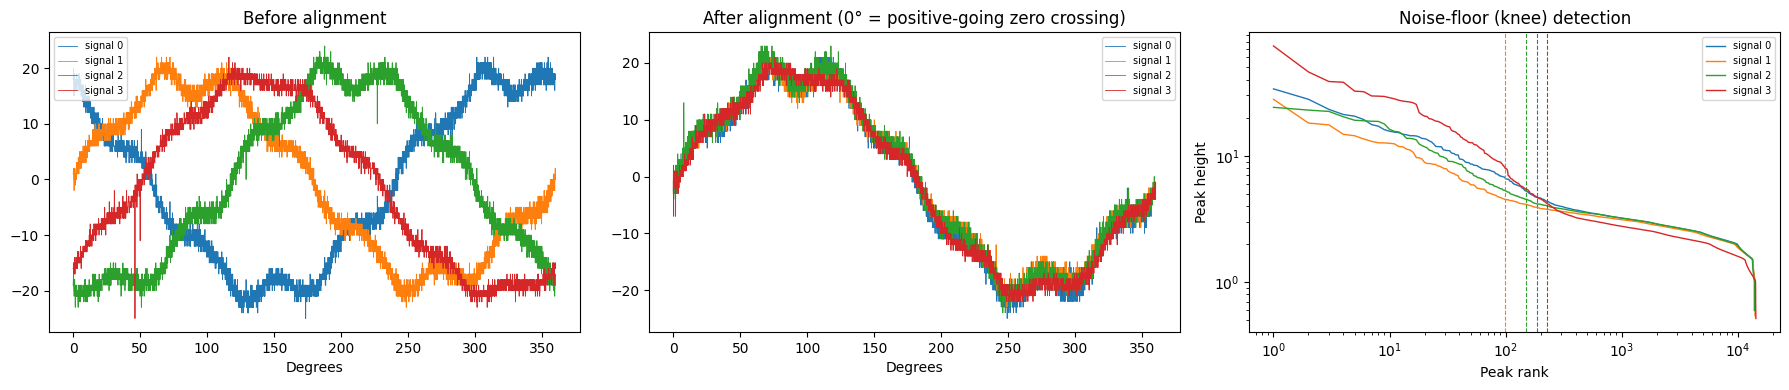

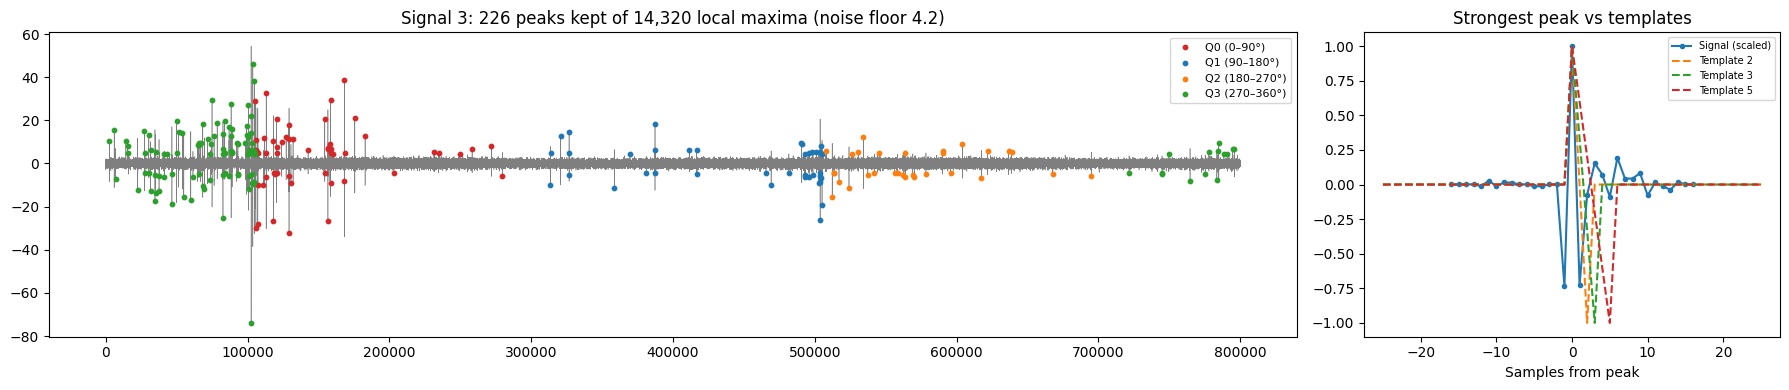

In [21]:
ids = meta['signal_id'].values[:4]
table = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(s) for s in ids])
deg = np.arange(0, N_SAMPLES, 200) / N_SAMPLES * 360
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for s in ids:
    raw = table.column(str(s)).to_numpy()
    phi, _, shift = phase_offset(raw)
    axes[0].plot(deg, raw[::200], linewidth=0.6, label=f'signal {s}')
    axes[1].plot(deg, np.roll(raw, -shift)[::200], linewidth=0.6, label=f'signal {s}')
    xa = np.abs(flatiron(raw.astype(np.float64))); h = np.sort(xa[local_maxima(xa)])[::-1]
    kept = peak_table(raw, phi)[2]['n_peaks']
    line, = axes[2].loglog(np.arange(1, len(h) + 1), h, linewidth=1, label=f'signal {s}')
    axes[2].axvline(max(kept, 1), color=line.get_color(), linestyle='--', linewidth=0.8)
axes[0].set_title('Before alignment'); axes[1].set_title('After alignment (0° = positive-going zero crossing)')
axes[2].set_title('Noise-floor (knee) detection'); axes[2].set_xlabel('Peak rank'); axes[2].set_ylabel('Peak height')
for ax in axes[:2]:
    ax.set_xlabel('Degrees')
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
feats, windows, stats, xh = peak_table(raw, phase_offset(raw)[0])
quarter = (feats['phase_deg'] // 90).astype(int).clip(0, 3)
fig, axes = plt.subplots(1, 2, figsize=(18, 4), gridspec_kw={'width_ratios': [3, 1]})
axes[0].plot(xh, linewidth=0.4, color='tab:gray')
for q, c in zip(range(4), ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']):
    sel = quarter == q
    axes[0].scatter(feats['px'][sel], xh[feats['px'][sel]], s=10, color=c, zorder=3, label=f'Q{q} ({q * 90}–{q * 90 + 90}°)')
axes[0].set_title(f'Signal {sid}: {stats["n_peaks"]} peaks kept of {stats["n_local_maxima"]:,} local maxima '
                  f'(noise floor {stats["knee_height"]:.1f})'); axes[0].legend(fontsize=8)
top = int(np.argmax(feats['height']))
shown = np.r_[np.full(LARGE_W - STORE_W, np.nan), windows[top].astype(float), np.full(LARGE_W - STORE_W, np.nan)]
axes[1].plot(off_l, shown, marker='o', markersize=3, label='Signal (scaled)')
for L, t in TEMPLATES.items():
    axes[1].plot(off_l, t, linestyle='--', label=f'Template {L}')
axes[1].set_xlabel('Samples from peak'); axes[1].set_title('Strongest peak vs templates'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6. Process all signals (one pass) and save

In [22]:
def run(parquet_file, ids, with_features):
    X = np.zeros((len(ids), N_CHUNKS, N_FEATURES), dtype=np.float32) if with_features else None
    offs, peak_frames, wins, stats_rows = [], [], [], []
    for start in tqdm(range(0, len(ids), 300), desc=parquet_file):
        batch = ids[start:start + 300]
        table = pq.read_table(f'{DATA_DIR}/{parquet_file}', columns=[str(s) for s in batch])
        for j, s in enumerate(batch):
            raw = table.column(str(s)).to_numpy()
            phi, amp, shift = phase_offset(raw)
            offs.append((s, phi, amp, shift, int(round(shift / CHUNK_LEN)) % N_CHUNKS))
            if with_features:
                X[start + j] = chunk_features(raw)
            feats, w, st, _ = peak_table(raw, phi)
            df = pd.DataFrame(feats); df.insert(0, 'signal_id', s)
            peak_frames.append(df); wins.append(w); stats_rows.append({'signal_id': s, **st})
        del table
    peaks = pd.concat(peak_frames, ignore_index=True)
    for c in ['height', 'ratio_next', 'ratio_prev', 'phase_deg'] + [f'sawtooth_{L}' for L in TEMPLATE_LENGTHS]:
        peaks[c] = peaks[c].astype(np.float32)
    for c, t in [('signal_id', np.int32), ('px', np.int32), ('sign', np.int8), ('small_dist_to_min', np.int8), ('width', np.int8)]:
        peaks[c] = peaks[c].astype(t)
    offsets = pd.DataFrame(offs, columns=['signal_id', 'phi_rad', 'amplitude', 'shift_samples', 'shift_chunks'])
    return X, offsets, peaks, np.concatenate(wins), pd.DataFrame(stats_rows)

run_meta = meta.iloc[:LIMIT] if LIMIT else meta
run_k = meta_k.iloc[:LIMIT] if LIMIT else meta_k
for name, m, file, xname in [('train', run_meta, 'train.parquet', 'X_train_v2.npy'),
                             ('kaggle_test', run_k, 'test.parquet', 'X_kaggle_test_v2.npy')]:
    X, offsets, peaks, wins, stats = run(file, m['signal_id'].values, not REUSE_FEATURES)
    if REUSE_FEATURES:
        shutil.copy(f'{SAVED_DIR}/{xname}', f'{OUT_DIR}/{xname}')
    else:
        np.save(f'{OUT_DIR}/{xname}', X)
    offsets.to_csv(f'{OUT_DIR}/phase_offsets_{name}.csv', index=False)
    peaks.to_parquet(f'{OUT_DIR}/peaks_{name}.parquet', index=False)
    np.save(f'{OUT_DIR}/windows_{name}.npy', wins)
    stats.to_csv(f'{OUT_DIR}/signals_{name}.csv', index=False)
    print(f'{name}: {len(m)} signals | {len(peaks):,} peaks | noise-floor fallback used for {stats["fallback"].sum()} signals')

with open(f'{OUT_DIR}/feature_names.json', 'w') as f:
    json.dump(FEATURE_NAMES, f)
run_meta.to_csv(f'{OUT_DIR}/meta_train_v2.csv', index=False)
run_meta.to_csv(f'{OUT_DIR}/meta_train.csv', index=False)
run_k.to_csv(f'{OUT_DIR}/meta_kaggle_test.csv', index=False)
t3 = glob.glob('/kaggle/input/**/test3_summary.csv', recursive=True)
if t3:
    shutil.copy(t3[0], f'{OUT_DIR}/test3_summary.csv'); print('Copied test3_summary.csv')
print('All outputs saved.')

train.parquet:   0%|          | 0/30 [00:00<?, ?it/s]

train: 8712 signals | 1,298,370 peaks | noise-floor fallback used for 8 signals


test.parquet:   0%|          | 0/68 [00:00<?, ?it/s]

kaggle_test: 20337 signals | 2,616,855 peaks | noise-floor fallback used for 9 signals
All outputs saved.


## 7. Checks

- **Start positions:** a spread across 0–360° confirms alignment is needed.
- **Weak 50 Hz waves:** signals whose 50 Hz amplitude is under 10% of the median (phase estimate less reliable).
- **Chunk features:** PD signals should average clearly more strong pulses than normal signals.
- **Peak table:** PD signals should have more kept peaks, especially in quarters Q0 and Q2.

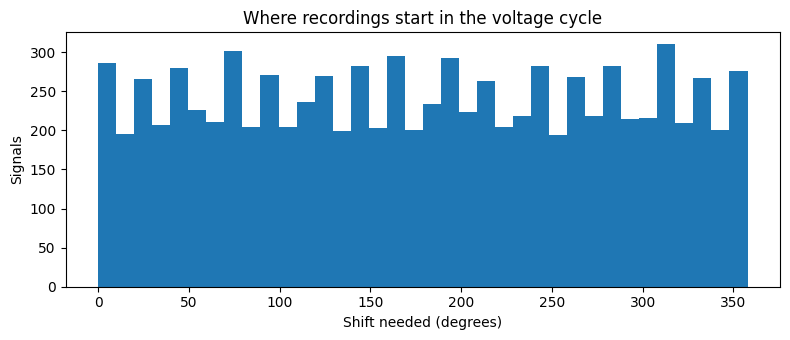

Median 50 Hz amplitude: 20.4 | weak 50 Hz waves: 58 of 29049
PD    : chunk features  545.2 strong pulses | peak table  436.0 peaks ( 193.0 in Q0+Q2)
Normal: chunk features  111.7 strong pulses | peak table  130.6 peaks (  63.2 in Q0+Q2)


In [23]:
off_tr = pd.read_csv(f'{OUT_DIR}/phase_offsets_train.csv'); off_k = pd.read_csv(f'{OUT_DIR}/phase_offsets_kaggle_test.csv')
plt.figure(figsize=(8, 3.5))
plt.hist(off_tr['shift_chunks'] * DEG_PER_CHUNK, bins=36, color='tab:blue')
plt.xlabel('Shift needed (degrees)'); plt.ylabel('Signals'); plt.title('Where recordings start in the voltage cycle')
plt.tight_layout(); plt.show()
amp = pd.concat([off_tr['amplitude'], off_k['amplitude']])
print(f'Median 50 Hz amplitude: {amp.median():.1f} | weak 50 Hz waves: {(amp < 0.1 * amp.median()).sum()} of {len(amp)}')

y_run = run_meta.set_index('signal_id')['target']
Xs = np.load(f'{OUT_DIR}/X_train_v2.npy')
strong = Xs[:, :, FEATURE_NAMES.index('pulses_8sd')].sum(axis=1)
p = pd.read_parquet(f'{OUT_DIR}/peaks_train.parquet')
p['Q02'] = (p['phase_deg'] // 90).astype(int).isin([0, 2])
per_sig = p.groupby('signal_id').agg(peaks=('px', 'size'), peaks_Q02=('Q02', 'sum')).reindex(run_meta['signal_id'], fill_value=0)
for label, name in [(1, 'PD'), (0, 'Normal')]:
    sel = run_meta['target'].values == label
    print(f'{name:6s}: chunk features {strong[sel].mean():6.1f} strong pulses | '
          f'peak table {per_sig["peaks"].values[sel].mean():6.1f} peaks ({per_sig["peaks_Q02"].values[sel].mean():6.1f} in Q0+Q2)')

## Next step

Set `LIMIT = None` and commit with **Save & Run All**, named for example `V8 - Data prep V4`. Then:
- **Test 4:** attach this output (remove Data prep v3), add the prediction-saving cell, and commit.
- **Test 5:** attach this output and the committed Test 4 output.